In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from copy import deepcopy
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import random

2026-03-01 22:00:01.725842: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 22:00:01.766501: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 22:00:02.554622: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### 1. Load data

In [2]:
X_train = np.load('../data/X_train.npy')
X_val   = np.load('../data/X_val.npy')

dim = X_train.shape[1]
print(f'Train : {X_train.shape}   Val : {X_val.shape}')
print(f'Input dimension: {dim}')

Train : (8739, 57)   Val : (972, 57)
Input dimension: 57


In [3]:
class Individual:
    def __init__(self, input_dim, chromosome=None):
        self.input_dim = input_dim
        if chromosome is None:
            self.chromosome = self.minimal_chromosome()
        else:
            self.chromosome = chromosome
        self.model = None
        self.fitness = None
        self.val_loss = None
        self.complexity = self.calculate_complexity()

    # Start with a minimal autoencoder (1 encoder layer), complexity will evolve eventually
    @staticmethod
    def minimal_chromosome():
        return {
            'num_layers': 1,
            'layer_sizes': [64],
            'activations': ['relu'],
            'dropout_rates': [0.1],
            'embedding_dim': 32,
            'learning_rate': 0.001,
            'batch_size': 128,
        }

    # Calculate network complexity for fitness penalty
    def calculate_complexity(self):
        c = self.chromosome
        # Encoder: input → hidden layers → embedding
        sizes = [self.input_dim] + c['layer_sizes'] + [c['embedding_dim']]
        num_params = sum(sizes[i] * sizes[i+1] for i in range(len(sizes) - 1))
        # Decoder mirrors the encoder
        num_params *= 2
        # Final reconstruction layer: embedding → input
        num_params += c['embedding_dim'] * self.input_dim
        return num_params

    # Build a symmetric autoencoder from chromosome
    def build_model(self):
        c = self.chromosome
        inp = layers.Input(shape=(self.input_dim,))
        x = inp

        # Encoder
        for i in range(c['num_layers']):
            x = layers.Dense(c['layer_sizes'][i], activation=c['activations'][i])(x)
            x = layers.Dropout(c['dropout_rates'][i])(x)
        embed = layers.Dense(c['embedding_dim'], activation='relu', name='embedding')(x)

        # Decoder (mirror)
        x = embed
        for i in range(c['num_layers'] - 1, -1, -1):
            x = layers.Dense(c['layer_sizes'][i], activation=c['activations'][i])(x)
            x = layers.Dropout(c['dropout_rates'][i])(x)
        out = layers.Dense(self.input_dim, activation='linear', name='reconstruction')(x)

        model = keras.Model(inputs=inp, outputs=out)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=c['learning_rate']),
            loss='mse',
            metrics=['mae']
        )
        self.model = model
        return model

    def calc_fitness(self, x_train, x_val, epochs=10, complexity_penalty=0.00001):
        if self.model is None:
            self.build_model()

        # Early stopping
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        # Train (autoencoder reconstructs its own input)
        history = self.model.fit(
            x_train, x_train,
            validation_data=(x_val, x_val),
            epochs=epochs,
            batch_size=self.chromosome['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Get the best validation loss
        val_loss = min(history.history['val_loss'])

        # Penalize complexity (prefer simpler networks)
        self.complexity = self.calculate_complexity()
        complexity_cost = complexity_penalty * self.complexity

        # Fitness = performance - complexity
        self.fitness = -(val_loss + complexity_cost)
        self.val_loss = val_loss
        return self.fitness

    def __lt__(self, other):
        return self.fitness < other.fitness

    def __repr__(self):
        return f"NEAT(fit={self.fitness:.4f}, loss={self.val_loss:.4f}, layers={self.chromosome['num_layers']}, embed={self.chromosome['embedding_dim']}, params={self.complexity})"

In [4]:
class GeneticAlgorithm:
    def __init__(
        self,
        population_size: int,
        num_generations: int,
        mutation_prob: float,
        add_node_prob: float,  # Probability of adding a layer
        elitism_size: float,
        selection_type: str = 'tournament',
        tournament_size: int = 3,
        training_epochs: int = 10,
        complexity_penalty: float = 0.00001,
    ):
        self.population_size = population_size
        self.num_elite = int(population_size * elitism_size)
        if self.num_elite % 2 != self.population_size % 2:
            self.num_elite += 1
        self.mutation_prob = mutation_prob
        self.add_node_prob = add_node_prob  # NEAT: structural mutation
        self.selection_type = selection_type
        self.tournament_size = tournament_size
        self.num_generations = num_generations
        self.training_epochs = training_epochs
        self.complexity_penalty = complexity_penalty

        self.history = {
        'best_fitness': [],
        'best_val_loss': [],
        'avg_complexity': [],
        'avg_layers': [],
        }

    def selection(self, population):
        if self.selection_type == 'tournament':
            participants = random.sample(population, self.tournament_size)
            return max(participants, key=lambda x: x.fitness)
        else:
            raise ValueError(f'unknown selection_type: {self.selection_type}')

    @staticmethod
    def crossover(parent1, parent2):
        fitter = parent1 if parent1.fitness > parent2.fitness else parent2
        weaker = parent2 if parent1.fitness > parent2.fitness else parent1

        # Start with fitter parent's structure
        child_chromo = deepcopy(fitter.chromosome)

        # Randomly inherit some traits from weaker parent
        if random.random() < 0.3:
            child_chromo['learning_rate'] = weaker.chromosome['learning_rate']

        if random.random() < 0.3:
            child_chromo['batch_size'] = weaker.chromosome['batch_size']

        if random.random() < 0.3:
            child_chromo['embedding_dim'] = weaker.chromosome['embedding_dim']

        # For layers that exist in both, maybe swap
        min_layers = min(len(parent1.chromosome['layer_sizes']),
                        len(parent2.chromosome['layer_sizes']))

        for i in range(min_layers):
            if random.random() < 0.3:
                child_chromo['layer_sizes'][i] = weaker.chromosome['layer_sizes'][i]
                child_chromo['activations'][i] = weaker.chromosome['activations'][i]
                child_chromo['dropout_rates'][i] = weaker.chromosome['dropout_rates'][i]

        return child_chromo

    # Add or remove layers
    def structural_mutation(self, chromosome):
        mutated = deepcopy(chromosome)

        if random.random() < self.add_node_prob:
            if mutated['num_layers'] < 5:  # Max 5 encoder layers
                mutated['num_layers'] += 1
                new_size = random.choice([64, 128])
                mutated['layer_sizes'].append(new_size)
                mutated['activations'].append('relu')
                mutated['dropout_rates'].append(random.uniform(0.2, 0.4))
                print(f"\tAdded layer! Now {mutated['num_layers']} layers", flush=True)

        elif random.random() < self.add_node_prob * 0.3:  # 30% chance compared to adding
            if mutated['num_layers'] > 1:
                mutated['num_layers'] -= 1
                mutated['layer_sizes'].pop()
                mutated['activations'].pop()
                mutated['dropout_rates'].pop()
                print(f"\tRemoved layer! Now {mutated['num_layers']} layers", flush=True)

        return mutated

    # Regular mutation
    def parameter_mutation(self, chromosome):
        mutated = deepcopy(chromosome)

        # Mutate learning rate
        if random.random() < self.mutation_prob:
            mutated['learning_rate'] = random.choice([0.0005, 0.001, 0.005])

        # Mutate batch size
        if random.random() < self.mutation_prob:
            mutated['batch_size'] = random.choice([128, 256])

        # Mutate embedding dim
        if random.random() < self.mutation_prob:
            mutated['embedding_dim'] = random.choice([16, 32, 64])

        # Mutate existing layers
        for i in range(len(mutated['layer_sizes'])):
            if random.random() < self.mutation_prob:
                mutated['layer_sizes'][i] = random.choice([64, 128, 256])

            if random.random() < self.mutation_prob:
                mutated['activations'][i] = random.choice(['relu', 'tanh'])

            if random.random() < self.mutation_prob:
                mutated['dropout_rates'][i] = random.uniform(0.2, 0.4)

        return mutated

    def solve(self, x_train, x_val):
        input_dim = x_train.shape[1]

        print(f"--- Starting evolution...")
        print(f"--- Population: {self.population_size}, Generations: {self.num_generations}")
        print(f"--- Starting with MINIMAL topology (1 encoder layer)\n")

        population = [Individual(input_dim) for _ in range(self.population_size)]

        # Evaluate initial population
        print("--- Evaluating minimal networks...")
        for i, ind in enumerate(population):
            ind.calc_fitness(x_train, x_val,
                           epochs=self.training_epochs,
                           complexity_penalty=self.complexity_penalty)
            print(f"\t[{i+1}/{self.population_size}] {ind}")

        best_overall = max(population, key=lambda x: x.fitness)

        # Evolution
        for gen in range(self.num_generations):
            print(f"\n{'='*70}")
            print(f"--- Generation {gen+1}/{self.num_generations}")
            print(f"{'='*70}")

            population.sort(reverse=True, key=lambda x: x.fitness)

            # Statistics
            avg_layers = np.mean([ind.chromosome['num_layers'] for ind in population])
            avg_complexity = np.mean([ind.complexity for ind in population])

            self.history['avg_layers'].append(avg_layers)
            self.history['avg_complexity'].append(avg_complexity)
            self.history['best_fitness'].append(population[0].fitness)
            self.history['best_val_loss'].append(population[0].val_loss)

            new_population = population[:self.num_elite]

            print(f"--- Top 3:")
            for i, ind in enumerate(population[:3]):
                print(f"  {i+1}. {ind}")

            print(f"\n--- Population Stats:")
            print(f"\tAvg Layers: {avg_layers:.2f}")
            print(f"\tAvg Params: {avg_complexity:.0f}")
            print(f"\tComplexity Range: {min(ind.complexity for ind in population)} - {max(ind.complexity for ind in population)}")

            # Generate children
            print(f"\n--- Generating children...")
            for i in range(self.num_elite, self.population_size):
                parent1 = self.selection(population)
                parent2 = self.selection(population)

                child_chromo = self.crossover(parent1, parent2)
                child_chromo = self.structural_mutation(child_chromo)
                child_chromo = self.parameter_mutation(child_chromo)

                child = Individual(input_dim, child_chromo)
                child.calc_fitness(x_train, x_val,
                                 epochs=self.training_epochs,
                                 complexity_penalty=self.complexity_penalty)

                print(f"\tChild {i-self.num_elite+1}: {child}")
                new_population.append(child)

            population = new_population

            current_best = max(population, key=lambda x: x.fitness)
            if current_best.fitness > best_overall.fitness:
                best_overall = deepcopy(current_best)
                print(f"\n\tNEW BEST: {best_overall}")

        return best_overall

In [5]:
SAMPLE_N = 5000
idx = np.random.choice(len(X_train), min(SAMPLE_N, len(X_train)), replace=False)
X_train_sample = X_train[idx]
X_val_sample   = X_val[:1000]

print(f'GA training sample: {X_train_sample.shape}')
print(f'GA val sample: {X_val_sample.shape}')

GA training sample: (5000, 57)
GA val sample: (972, 57)


In [6]:
ga = GeneticAlgorithm(
    population_size = 10,
    num_generations = 8,
    mutation_prob = 0.2,
    add_node_prob = 0.3,
    elitism_size = 0.2,
    selection_type = 'tournament',
    tournament_size = 3,
    training_epochs = 12,
    complexity_penalty = 0.000001,
)

best = ga.solve(X_train_sample, X_val_sample)

print('\n' + '='*65)
print('EVOLUTION COMPLETE')
print('='*65)
print(f'Best chromosome: {best.chromosome}')

--- Starting evolution...
--- Population: 10, Generations: 8
--- Starting with MINIMAL topology (1 encoder layer)

--- Evaluating minimal networks...
	[1/10] NEAT(fit=-0.0280, loss=0.0148, layers=1, embed=32, params=13216)
	[2/10] NEAT(fit=-0.0278, loss=0.0146, layers=1, embed=32, params=13216)
	[3/10] NEAT(fit=-0.0282, loss=0.0150, layers=1, embed=32, params=13216)
	[4/10] NEAT(fit=-0.0292, loss=0.0160, layers=1, embed=32, params=13216)
	[5/10] NEAT(fit=-0.0284, loss=0.0152, layers=1, embed=32, params=13216)
	[6/10] NEAT(fit=-0.0288, loss=0.0156, layers=1, embed=32, params=13216)
	[7/10] NEAT(fit=-0.0287, loss=0.0155, layers=1, embed=32, params=13216)
	[8/10] NEAT(fit=-0.0287, loss=0.0155, layers=1, embed=32, params=13216)
	[9/10] NEAT(fit=-0.0281, loss=0.0148, layers=1, embed=32, params=13216)
	[10/10] NEAT(fit=-0.0276, loss=0.0144, layers=1, embed=32, params=13216)

--- Generation 1/8
--- Top 3:
  1. NEAT(fit=-0.0276, loss=0.0144, layers=1, embed=32, params=13216)
  2. NEAT(fit=-0.0

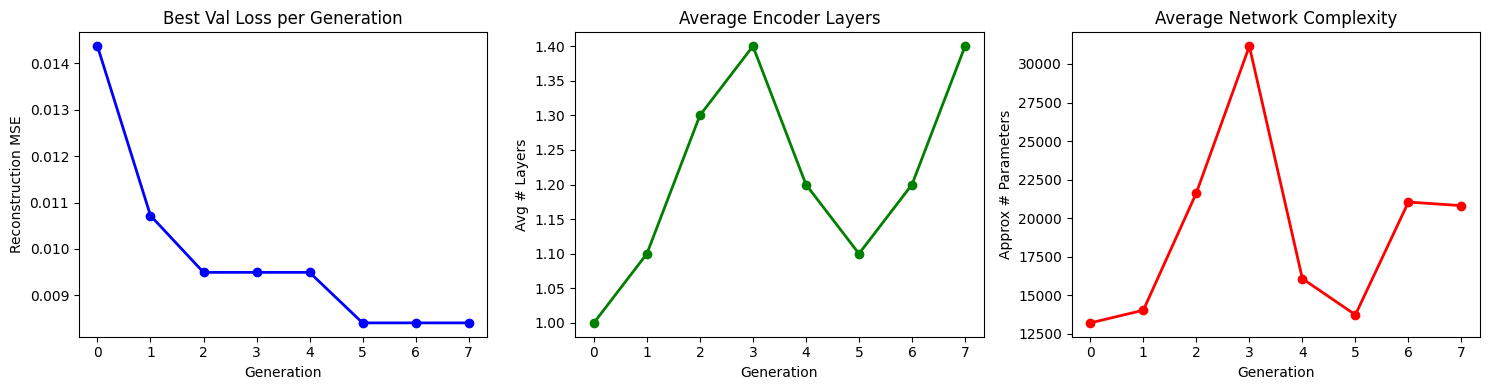

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ga.history['best_val_loss'], 'b-o', linewidth=2)
axes[0].set_title('Best Val Loss per Generation')
axes[0].set_xlabel('Generation'); axes[0].set_ylabel('Reconstruction MSE')

axes[1].plot(ga.history['avg_layers'], 'g-o', linewidth=2)
axes[1].set_title('Average Encoder Layers')
axes[1].set_xlabel('Generation'); axes[1].set_ylabel('Avg # Layers')

axes[2].plot(ga.history['avg_complexity'], 'r-o', linewidth=2)
axes[2].set_title('Average Network Complexity')
axes[2].set_xlabel('Generation'); axes[2].set_ylabel('Approx # Parameters')

plt.tight_layout()
plt.show()

In [8]:
# Rebuild a fresh model with the best chromosome
best.model = None
best.build_model()
best.model.summary()

history_full = best.model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=best.chromosome['batch_size'],
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    ],
    verbose=1
)

final_val = min(history_full.history['val_loss'])
print(f'\nFinal val MSE: {final_val:.5f}')
print(f'Architecture: {best.chromosome["num_layers"]} encoder layers, embed_dim={best.chromosome["embedding_dim"]}')
print(f'Parameters: ~{best.complexity:,}')

Model: "functional_149"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_74 (InputLayer)     │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (None, 64)             │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_182 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_183 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 57)             │         3,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,609 (45.35 KB)

 Trainable params: 11,609 (45.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0506 - mae: 0.1529 - val_loss: 0.0174 - val_mae: 0.0938 - learning_rate: 0.0050
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0187 - mae: 0.1007 - val_loss: 0.0111 - val_mae: 0.0739 - learning_rate: 0.0050
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0139 - mae: 0.0869 - val_loss: 0.0095 - val_mae: 0.0673 - learning_rate: 0.0050
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0124 - mae: 0.0818 - val_loss: 0.0085 - val_mae: 0.0628 - learning_rate: 0.0050
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - mae: 0.0787 - val_loss: 0.0083 - val_mae: 0.0613 - learning_rate: 0.0050
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0112 - mae: 0.0767 - val_loss: 0.0082 - val_mae: 0.0607 - learning_rate: 0.0050
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0108 - mae: 0.0751 - val_loss: 0.0081 - val_mae: 0.0599 - learning_rate: 0.0050
Epoch 8/100
6

In [9]:
# Extract encoder from best autoencoder
inp = best.model.input
embed = best.model.get_layer('embedding').output
best_encoder = keras.Model(inputs=inp, outputs=embed, name='best_encoder')

# Generate new embeddings with the GA-optimised encoder
feature_df = pd.read_csv('../data/movie_features.csv')
with open('../data/feature_cols.txt') as f:
    feature_cols = f.read().splitlines()

X_all = feature_df[feature_cols].values.astype(np.float32)
embeds = best_encoder.predict(X_all, batch_size=256, verbose=0)
norms = np.linalg.norm(embeds, axis=1, keepdims=True) + 1e-8
embeddings_ga = embeds / norms

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend(liked_titles, top_n=10, df=feature_df, embeddings=embeddings_ga):
    liked_ids, liked_vecs = [], []
    for title in liked_titles:
        matches = df[df['title'].str.lower().str.contains(title.lower(), regex=False)]
        if matches.empty:
            print(f'  Warning: "{title}" not found — skipping.')
            continue
        row = matches.iloc[0]
        liked_ids.append(row['movieId'])
        liked_vecs.append(embeddings[row.name])
        print(f'  Matched: {row["title"]} ({int(row["year"])})')
    if not liked_vecs:
        return pd.DataFrame()
    query  = np.mean(liked_vecs, axis=0, keepdims=True)
    query /= (np.linalg.norm(query) + 1e-8)
    sims   = cosine_similarity(query, embeddings)[0]
    result = df[['movieId','title','genres','year']].copy()
    result['similarity'] = sims
    result = result[~result['movieId'].isin(liked_ids)]
    result = result.sort_values('similarity', ascending=False).head(top_n)
    result['year'] = result['year'].astype(int)
    result['similarity'] = result['similarity'].round(4)
    return result.reset_index(drop=True)

print('Test: Inception + The Matrix\n')
recs = recommend(['Inception', 'Matrix'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

Test: Inception + The Matrix

  Matched: Inception (2010) (2010)
  Matched: Matrix, The (1999) (1999)
                       title                                    genres  year  similarity
       V for Vendetta (2006)               Action|Sci-Fi|Thriller|IMAX  2006      0.9655
             Watchmen (2009) Action|Drama|Mystery|Sci-Fi|Thriller|IMAX  2009      0.9590
X-Men: The Last Stand (2006)                    Action|Sci-Fi|Thriller  2006      0.9572
      Minority Report (2002)      Action|Crime|Mystery|Sci-Fi|Thriller  2002      0.9539
          Equilibrium (2002)                    Action|Sci-Fi|Thriller  2002      0.9531
         Transformers (2007)               Action|Sci-Fi|Thriller|IMAX  2007      0.9523
      Terminator, The (1984)                    Action|Sci-Fi|Thriller  1984      0.9516
         Blade Runner (1982)                    Action|Sci-Fi|Thriller  1982      0.9495
             Predator (1987)                    Action|Sci-Fi|Thriller  1987      0.9495
        

In [12]:
recs = recommend(['Interstellar'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Interstellar (2014) (2014)
                                                                    title             genres  year  similarity
                                                           Arrival (2016)             Sci-Fi  2016      0.9733
                                                 Blade Runner 2049 (2017)             Sci-Fi  2017      0.9638
                                    Dawn of the Planet of the Apes (2014)             Sci-Fi  2014      0.9354
                                                       Cloud Atlas (2012)  Drama|Sci-Fi|IMAX  2012      0.9257
                                                  Edge of Tomorrow (2014) Action|Sci-Fi|IMAX  2014      0.9207
                                     Doctor Who: The Runaway Bride (2007)             Sci-Fi  2007      0.9145
                                                         Limitless (2011)    Sci-Fi|Thriller  2011      0.9140
                                                           Gravity (2013) 

In [13]:
recs = recommend(['Good Will Hunting', 'Prestige', 'Interstellar'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Good Will Hunting (1997) (1997)
  Matched: Prestige, The (2006) (2006)
  Matched: Interstellar (2014) (2014)
                                       title                        genres  year  similarity
Eternal Sunshine of the Spotless Mind (2004)          Drama|Romance|Sci-Fi  2004      0.9517
                         Donnie Darko (2001) Drama|Mystery|Sci-Fi|Thriller  2001      0.9383
                          Unbreakable (2000)                  Drama|Sci-Fi  2000      0.9301
                 The Butterfly Effect (2004)         Drama|Sci-Fi|Thriller  2004      0.9287
                              Gattaca (1997)         Drama|Sci-Fi|Thriller  1997      0.9201
                          Cloud Atlas (2012)             Drama|Sci-Fi|IMAX  2012      0.9161
                                 Moon (2009) Drama|Mystery|Sci-Fi|Thriller  2009      0.9132
                              Contact (1997)                  Drama|Sci-Fi  1997      0.9085
                        Perfect Sense (2011

In [14]:
recs = recommend(['Loving Vincent', 'Ameli', 'Princess Mononoke'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Loving Vincent (2017) (2017)
  Matched: Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) (2001)
  Matched: Princess Mononoke (Mononoke-hime) (1997) (1997)
                                                                title                                            genres  year  similarity
Man Who Planted Trees, The (Homme qui plantait des arbres, L') (1987)                                   Animation|Drama  1987      0.8778
                      Ernest & Célestine (Ernest et Célestine) (2012) Adventure|Animation|Children|Comedy|Drama|Romance  2012      0.8712
                                                  Mary and Max (2009)                            Animation|Comedy|Drama  2009      0.8705
                                Wind Rises, The (Kaze tachinu) (2013)                           Animation|Drama|Romance  2013      0.8696
                       Whisper of the Heart (Mimi wo sumaseba) (1995)                           Animation|Drama|Romance  1995      0.8650
  

In [19]:
recs = recommend(['La vie en rose', 'Lord of the rings', 'The hunger games'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Lord of the Rings, The (1978) (1978)
  Matched: The Hunger Games (2012) (2012)
                                                    title                                             genres  year  similarity
                                        Titan A.E. (2000)         Action|Adventure|Animation|Children|Sci-Fi  2000      0.9422
Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986) Action|Adventure|Animation|Children|Fantasy|Sci-Fi  1986      0.9373
                                   Iron Giant, The (1999)          Adventure|Animation|Children|Drama|Sci-Fi  1999      0.9262
                                     Incredibles 2 (2018)                Action|Adventure|Animation|Children  2018      0.9218
                                    Watership Down (1978)         Adventure|Animation|Children|Drama|Fantasy  1978      0.9210
                                   Children of Men (2006)             Action|Adventure|Drama|Sci-Fi|Thriller  2006      0.9170
                     

In [28]:
recs = recommend(['zootopia'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Zootopia (2016) (2016)
                                     title                                             genres  year  similarity
                               Bolt (2008)         Action|Adventure|Animation|Children|Comedy  2008      0.9844
                   Incredibles, The (2004)         Action|Adventure|Animation|Children|Comedy  2004      0.9700
                              Rango (2011) Action|Adventure|Animation|Children|Comedy|Western  2011      0.9600
                    Kung Fu Panda 2 (2011)    Action|Adventure|Animation|Children|Comedy|IMAX  2011      0.9539
                      Incredibles 2 (2018)                Action|Adventure|Animation|Children  2018      0.9523
                     The Lego Movie (2014) Action|Adventure|Animation|Children|Comedy|Fantasy  2014      0.9504
        Madagascar: Escape 2 Africa (2008)    Action|Adventure|Animation|Children|Comedy|IMAX  2008      0.9484
                       Paddington 2 (2017)                Adventure|An

In [29]:
recs = recommend(['blue caftan', 'grand budapest hotel'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Grand Budapest Hotel, The (2014) (2014)
                                                  title       genres  year  similarity
                                           50/50 (2011) Comedy|Drama  2011      0.9653
                         Silver Linings Playbook (2012) Comedy|Drama  2012      0.9631
                                    Intouchables (2011) Comedy|Drama  2011      0.9553
         Great Beauty, The (Grande Bellezza, La) (2013) Comedy|Drama  2013      0.9500
                         Jeff, Who Lives at Home (2012) Comedy|Drama  2012      0.9494
                                   Men & Chicken (2015) Comedy|Drama  2015      0.9440
Birdman: Or (The Unexpected Virtue of Ignorance) (2014) Comedy|Drama  2014      0.9433
                                  Rocket Science (2007) Comedy|Drama  2007      0.9428
                              The African Doctor (2016) Comedy|Drama  2016      0.9427
                     Adam's Apples (Adams æbler) (2005) Comedy|Drama  2005     

In [30]:
recs = recommend(['titanic'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Titanic (1997) (1997)
                                   title        genres  year  similarity
                Good Will Hunting (1997) Drama|Romance  1997      0.9849
                Beautiful Mind, A (2001) Drama|Romance  2001      0.9815
Room in Rome (Habitación en Roma) (2010) Drama|Romance  2010      0.9792
                  American Beauty (1999) Drama|Romance  1999      0.9729
           Rachel Getting Married (2008) Drama|Romance  2008      0.9703
                    Jerry Maguire (1996) Drama|Romance  1996      0.9662
                         Chocolat (2000) Drama|Romance  2000      0.9657
                     Duchess, The (2008) Drama|Romance  2008      0.9539
                    Notebook, The (2004) Drama|Romance  2004      0.9523
            Sense and Sensibility (1995) Drama|Romance  1995      0.9505
